In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import contractions
import textstat

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
import torch

sns.set_style("whitegrid")

In [12]:
column_names = [
    'id',
    'label',
    'statement',
    'subjects',
    'speaker',
    'speaker_job',
    'state_info',
    'party_affiliation',
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_on_fire_counts',
    'context'
]

train_df = pd.read_csv('E:\\DUK\\S2\\Predictive\\Fake_News_Detection\\Dataset\\train.tsv', sep='\t', header=None)
valid_df = pd.read_csv('E:\\DUK\\S2\\Predictive\\Fake_News_Detection\\Dataset\\valid.tsv', sep='\t', header=None)
test_df = pd.read_csv('E:\\DUK\\S2\\Predictive\\Fake_News_Detection\\Dataset\\test.tsv', sep='\t', header=None)

train_df.columns = column_names
valid_df.columns = column_names
test_df.columns = column_names

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(10240, 14)
(1284, 14)
(1267, 14)


In [14]:
train_df.head()

,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


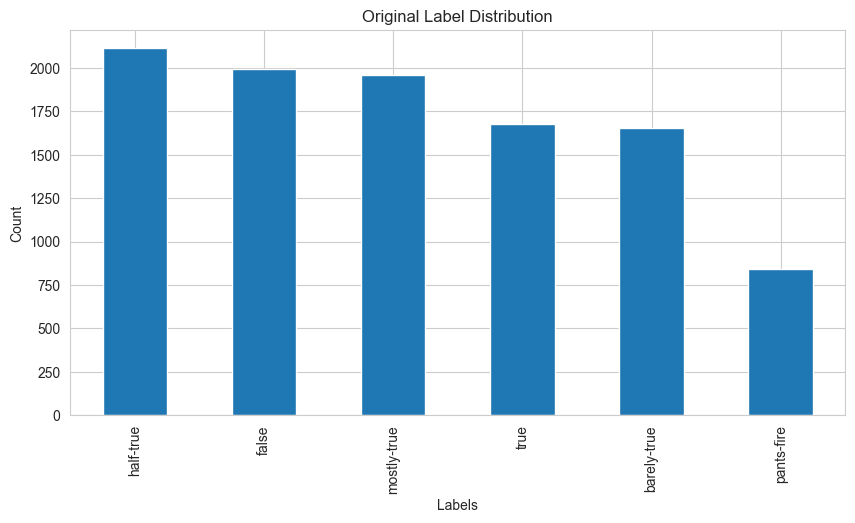

In [15]:
plt.figure(figsize=(10,5))
train_df['label'].value_counts().plot(kind='bar')
plt.title('Original Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

Convert Multi-Class to Binary Labels

In [17]:
fake_labels = ['pants-fire', 'false', 'barely-true']
real_labels = ['half-true', 'mostly-true', 'true']


def convert_label(label):
    if label in fake_labels:
        return 0
    else:
        return 1


train_df['target'] = train_df['label'].apply(convert_label)
valid_df['target'] = valid_df['label'].apply(convert_label)
test_df['target'] = test_df['label'].apply(convert_label)

train_df[['label', 'target']].head()

,label,target
0,false,0
1,half-true,1
2,mostly-true,1
3,false,0
4,half-true,1


Text Cleaning Function

In [18]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = str(text).lower()

    text = contractions.fix(text)

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Apply Cleaning

In [19]:
train_df['clean_text'] = train_df['statement'].apply(clean_text)
valid_df['clean_text'] = valid_df['statement'].apply(clean_text)
test_df['clean_text'] = test_df['statement'].apply(clean_text)

train_df[['statement', 'clean_text']].head()

,statement,clean_text
0,Says the Annies List political group supports ...,says annies list political group supports thir...
1,When did the decline of coal start? It started...,decline coal start started natural gas took st...
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees john mccain voting give...
3,Health care reform legislation is likely to ma...,health care reform legislation likely mandate ...
4,The economic turnaround started at the end of ...,economic turnaround started end term


Linguistic Feature Engineering

In [20]:

def extract_features(text):

    text = str(text)

    num_chars = len(text)
    num_words = len(text.split())
    num_sentences = len(re.split(r'[.!?]+', text))

    avg_word_length = np.mean([len(word) for word in text.split()]) if num_words > 0 else 0

    exclamation_count = text.count('!')
    question_count = text.count('?')
    capital_ratio = sum(1 for c in text if c.isupper()) / (len(text)+1)

    readability = textstat.flesch_reading_ease(text)

    return pd.Series([
        num_chars,
        num_words,
        num_sentences,
        avg_word_length,
        exclamation_count,
        question_count,
        capital_ratio,
        readability
    ])

Create Feature Columns

In [21]:
feature_names = [
    'num_chars',
    'num_words',
    'num_sentences',
    'avg_word_length',
    'exclamation_count',
    'question_count',
    'capital_ratio',
    'readability'
]

train_df[feature_names] = train_df['statement'].apply(extract_features)
valid_df[feature_names] = valid_df['statement'].apply(extract_features)
test_df[feature_names] = test_df['statement'].apply(extract_features)

train_df.head()

,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,...,target,clean_text,num_chars,num_words,num_sentences,avg_word_length,exclamation_count,question_count,capital_ratio,readability
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,...,0,says annies list political group supports thir...,82.0,11.0,2.0,6.545455,0.0,0.0,0.036145,49.542727
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,...,1,decline coal start started natural gas took st...,141.0,24.0,4.0,4.916667,0.0,1.0,0.042254,60.705000
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,...,1,hillary clinton agrees john mccain voting give...,105.0,19.0,2.0,4.578947,0.0,0.0,0.075472,62.876316
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,...,0,health care reform legislation likely mandate ...,78.0,12.0,2.0,5.583333,0.0,0.0,0.012658,53.655000
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,...,1,economic turnaround started end term,54.0,10.0,2.0,4.500000,0.0,0.0,0.018182,61.325000


Compare Linguistic Features

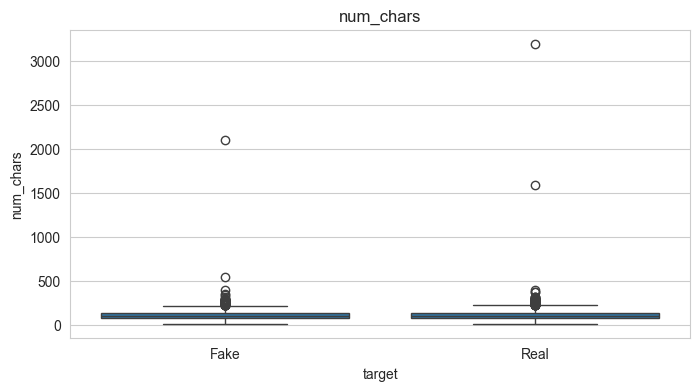

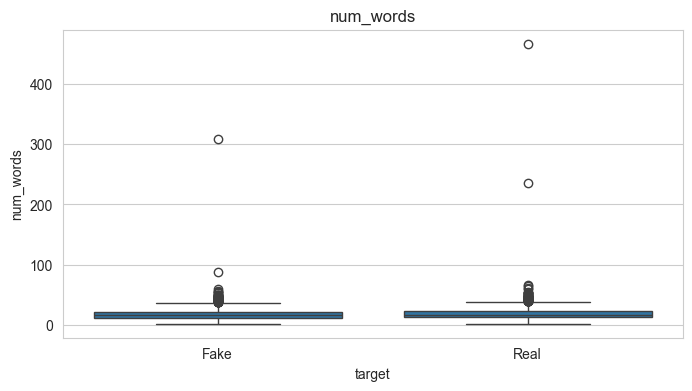

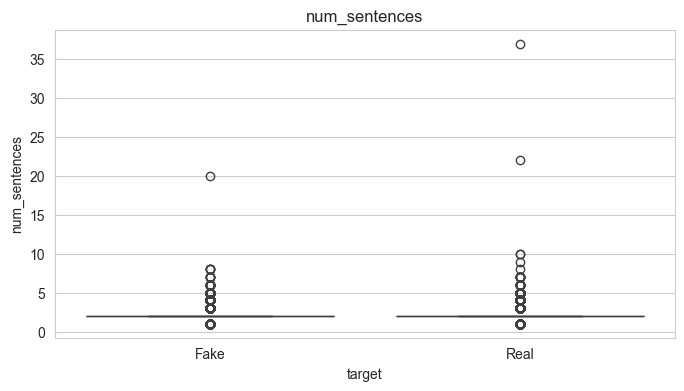

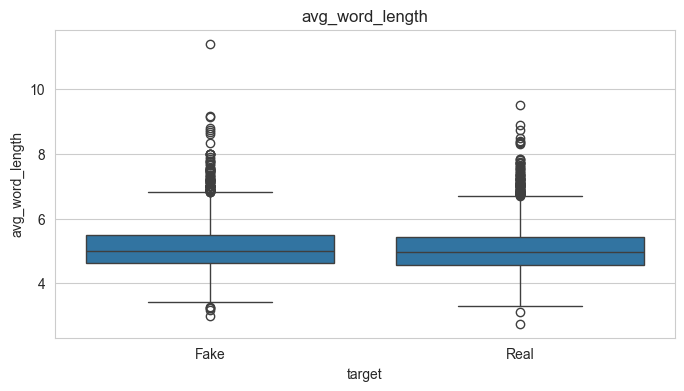

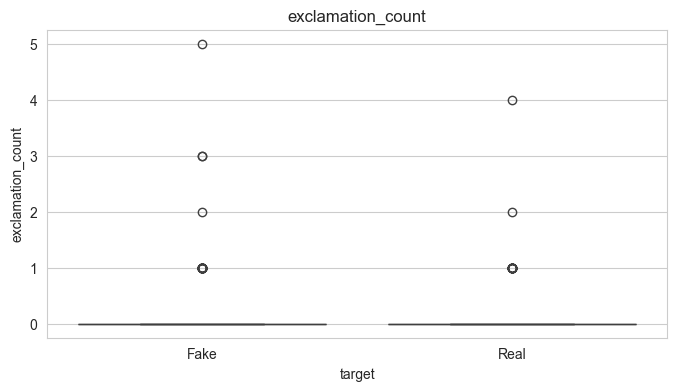

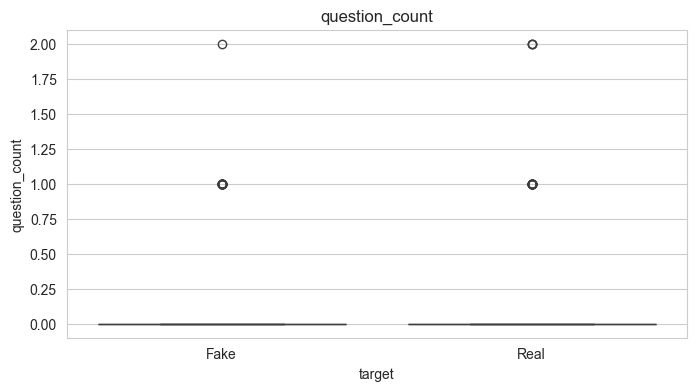

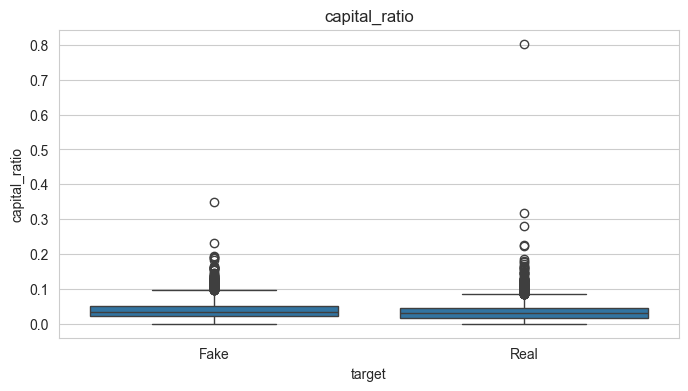

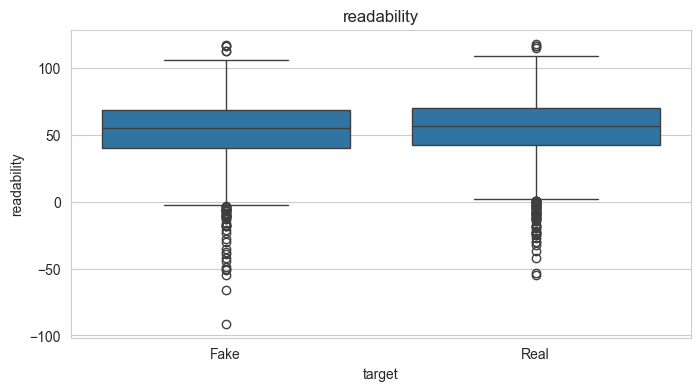

In [22]:
for feature in feature_names:

    plt.figure(figsize=(8,4))

    sns.boxplot(x='target', y=feature, data=train_df)

    plt.xticks([0,1], ['Fake', 'Real'])
    plt.title(feature)

    plt.show()

Word Cloud for Fake News

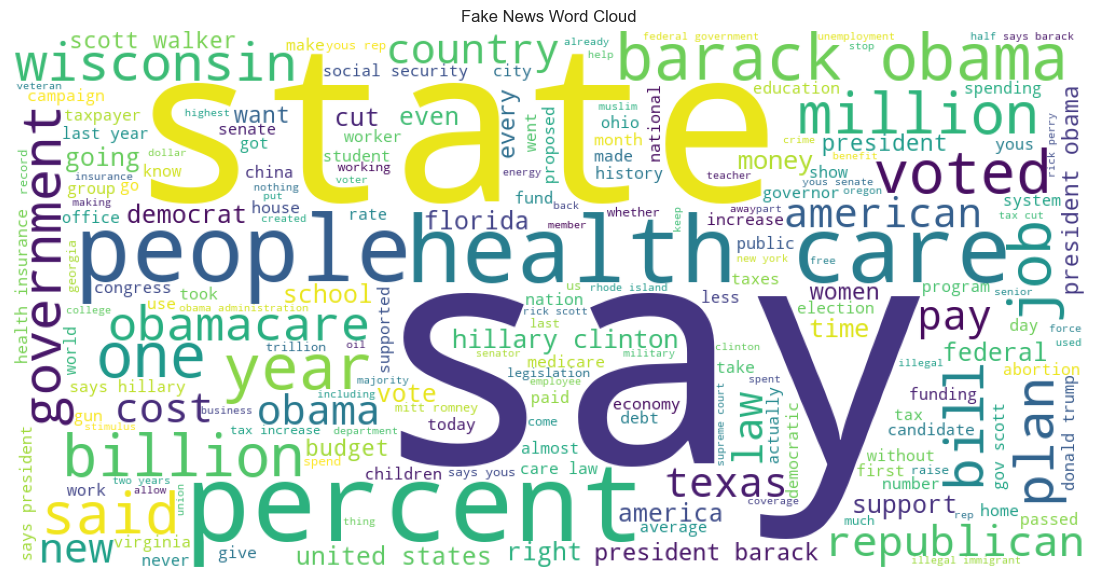

In [23]:
fake_text = ' '.join(train_df[train_df['target']==0]['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Fake News Word Cloud')
plt.show()

Word Cloud for Real News

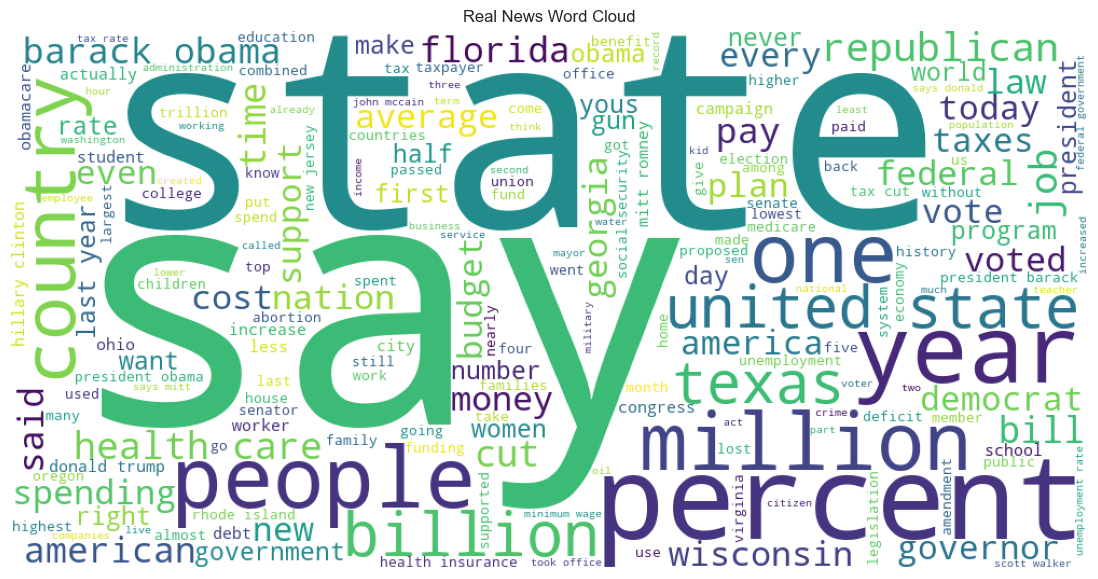

In [24]:
real_text = ' '.join(train_df[train_df['target']==1]['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Real News Word Cloud')
plt.show()

TF-IDF Vectorization

In [25]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(train_df['clean_text'])
X_valid_tfidf = vectorizer.transform(valid_df['clean_text'])
X_test_tfidf = vectorizer.transform(test_df['clean_text'])

y_train = train_df['target']
y_valid = valid_df['target']
y_test = test_df['target']